# 1. Introduction and research question

In this first project in Empirical Methods in Finance, we investigate whether oil price increases have different effects on the North American equity market and credit risk depending on whether those shocks are driven by demand or supply factors.

**Research question:** Do oil price increases have the same effect on financial markets when they are associated with stronger demand conditions as when they come from residual non-demand-related movements? Can this distinction improve the prediction of equity returns and credit spreads?

This Jupyter notebook is structured as follows:

1. Introduction and research question
2. Imports and setup
3. Constants and helper functions
4. Data loading
5. Data cleaning and monthly aggregation
6. Variable construction
7. Descriptive statistics and diagnostics
8. Oil shock decomposition
9. Predictive regressions
10. Causality tests
11. Small VARs and impulse responses
12. Out-of-sample forecasting
13. Robustness checks
14. Main conclusions

# 2. Imports and setup
First we need to import the correct packages and define options for the plots and pandas.

In [55]:
%matplotlib inline

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from scipy.optimize import minimize

warnings.filterwarnings("ignore")
plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.4f}".format)

# 3. Constants and helper functions

In this section, we define constants and create helper functions that will be used throughout the project.

## 3a. Constants

In [56]:
DAILY_COLUMNS = [
    "date", "wti", "brent", "sp500", "msci_em",
    "us10y", "us2y", "hy_ytw", "gold",
]

MONTHLY_COLUMNS = ["date", "cfnai", "ism_mfg"]

SHEET_USECOLS = {
    "Daily": [0, 1, 2, 6, 8, 10, 11, 12, 13],
    "Monthly": [0, 2, 3],
}

## 3b. Data loading

In [57]:
def load_data_sheet(excel_path, sheet_name, columns):
    raw = pd.read_excel(
        excel_path, sheet_name=sheet_name, header=None,
        usecols=SHEET_USECOLS[sheet_name],
    )
    data = raw.iloc[5:].copy()
    data.columns = columns

    first_value = str(data.iloc[0, 0]).strip().lower()
    if first_value == "dates":
        data = data.iloc[1:].copy()

    data["date"] = pd.to_datetime(data["date"])
    for column in columns[1:]:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    data = data.sort_values("date").reset_index(drop=True)
    return data

In [58]:
def aggregate_daily_to_monthly(daily_df):
    monthly_data = daily_df.resample("ME", on="date").last().reset_index()  # on garde la derniere observation de chaque mois pour les series de marche

    sp500_daily_returns = daily_df[["date", "sp500"]].copy()  # on isole le S&P 500 pour calculer une volatilite realisee mensuelle
    sp500_daily_returns["sp500_daily_log_return"] = np.log(sp500_daily_returns["sp500"]).diff()  # on calcule les rendements journaliers en log

    monthly_volatility = (
        sp500_daily_returns.resample("ME", on="date")["sp500_daily_log_return"]
        .std()  # l'ecart-type intra-mensuel des rendements sert de mesure simple de volatilite realisee
        .rename("sp500_realized_vol")
        .reset_index()
    )

    monthly_data = monthly_data.merge(monthly_volatility, on="date", how="left")  # on ajoute la volatilite mensuelle au panel agrege
    return monthly_data

## 3c. Variable construction
Define the log return, the spread of UST (10y - 2y) and the month-over-month change in the high yield bonds

In [59]:
def add_log_return(df, price_column, new_column):
    df[new_column] = np.log(df[price_column] / df[price_column].shift(1))

In [60]:
def build_project_variables(monthly_df):
    df = monthly_df.copy()
    df = df.sort_values("date").reset_index(drop=True)

    add_log_return(df, "wti", "wti_return")
    add_log_return(df, "brent", "brent_return")
    add_log_return(df, "sp500", "sp500_return")
    add_log_return(df, "msci_em", "msci_em_return")
    add_log_return(df, "gold", "gold_return")

    df["term_spread"] = df["us10y"] - df["us2y"]
    df["hy_change"] = df["hy_ytw"].diff()

    print("\nCheck of expected columns after variable construction:")
    expected_columns = [
        "wti_return", "brent_return", "sp500_return", "msci_em_return",
        "gold_return", "term_spread", "hy_change", "sp500_realized_vol",
        "cfnai", "ism_mfg",
    ]
    for column in expected_columns:
        print(f"{column}: {'OK' if column in df.columns else 'MISSING'}")

    return df

## 3d. ADF stationarity tests
Check whether our time series is stationary

In [61]:
def run_adf_table(df, columns):
    rows = []
    for column in columns:
        series = df[column].dropna()
        if len(series) < 20:
            rows.append({"variable": column, "n_obs": len(series), "adf_stat": np.nan, "p_value": np.nan, "stationary_5pct": np.nan})
            continue
        result = adfuller(series, autolag="AIC")
        rows.append({"variable": column, "n_obs": len(series), "adf_stat": round(result[0], 4), "p_value": round(result[1], 4), "stationary_5pct": result[1] < 0.05})
    return pd.DataFrame(rows)

## 3e. Descriptive diagnostics (raw variables)

**Jarque-Bera :**  Test for normality

**Ljung-Box :** Test for autocorrelation

In [62]:
def run_ljungbox_jb_table(df, columns, lags=(6, 12)):
    rows = []
    for col in columns:
        s = df[col].dropna()
        if len(s) < 20:
            continue
        lb = acorr_ljungbox(s, lags=list(lags), return_df=True)
        jb_stat, jb_p = stats.jarque_bera(s.values)
        row = {"variable": col}
        for lag in lags:
            row[f"LB({lag})_stat"] = round(float(lb.loc[lag, "lb_stat"]), 2)
            row[f"LB({lag})_pval"] = round(float(lb.loc[lag, "lb_pvalue"]), 4)
        row["JB_stat"] = round(float(jb_stat), 2)
        row["JB_pval"] = float(jb_p)
        row["normal_5pct"] = jb_p > 0.05
        rows.append(row)
    return pd.DataFrame(rows)

In [63]:
def plot_level_series(monthly_market_data):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axes[0].plot(monthly_market_data["date"], monthly_market_data["wti"], color="tab:blue")
    axes[0].set_title("WTI level")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(monthly_market_data["date"], monthly_market_data["sp500"], color="tab:green")
    axes[1].set_title("S&P 500 level")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("Figure 1. Raw market series in levels", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

## 3f. OLS regression
OLS Regression from scratch as seen in class

In [64]:
def ols_from_scratch(y, X, x_names=None):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y = y[mask]
    X = X[mask]

    T = len(y)
    Xc = np.column_stack([np.ones(T), X])  # on ajoute la constante manuellement pour reproduire la logique OLS du cours
    XtX_inv = np.linalg.inv(Xc.T @ Xc)
    beta = XtX_inv @ (Xc.T @ y)
    fitted = Xc @ beta
    resid = y - fitted

    SSR = resid @ resid
    SST = ((y - y.mean()) @ (y - y.mean()))
    R2 = 1.0 - SSR / SST
    sigma2 = SSR / (T - X.shape[1] - 1)
    var_beta = sigma2 * XtX_inv
    se = np.sqrt(np.diag(var_beta))
    t_stat = beta / se
    p_value = 2.0 * (1.0 - stats.t.cdf(np.abs(t_stat), df=T - X.shape[1] - 1))

    names = ["const"] + (x_names if x_names else [f"x{i}" for i in range(X.shape[1])])
    return {
        "beta": beta,
        "se": se,
        "t_stat": t_stat,
        "p_value": p_value,
        "resid": resid,
        "fitted": fitted,
        "R2": R2,
        "sigma2": sigma2,
        "T": T,
        "names": names,
        "X": Xc,
        "y": y,
    }

In [65]:
def ols_summary_df(res):
    return pd.DataFrame({
        "coef": res["beta"],
        "std_err": res["se"],
        "t_stat": res["t_stat"],
        "p_value": res["p_value"],
    }, index=res["names"]).round(4)

## 3g. Residual diagnostics
**Ljung-Box :** Test for autocorrelation on the residuals

In [66]:
def run_diagnostic_residuals(resid, lags=(6, 12)):
    resid = np.asarray(resid).flatten()
    resid = resid[np.isfinite(resid)]
    lb = acorr_ljungbox(resid, lags=list(lags), return_df=True)
    acf_values = acf(resid, nlags=max(lags), fft=True)
    rows = []
    for lag in lags:
        rows.append({"lag": lag, "ACF": round(float(acf_values[lag]), 4), "LB_stat": round(float(lb.loc[lag, "lb_stat"]), 2), "LB_pval": round(float(lb.loc[lag, "lb_pvalue"]), 4), "autocorrelated_5pct": lb.loc[lag, "lb_pvalue"] < 0.05})
    return pd.DataFrame(rows)

## 3h. MA(1)
Build the MA(1) from scratch using the MLE, define a robustness check and compare with the OLS

In [67]:
def ma_innovations(u, theta):
    T = len(u)
    eps = np.zeros(T)
    eps[0] = u[0]
    for t in range(1, T):
        eps[t] = u[t] - theta * eps[t - 1]
    return eps

In [68]:
def _loglik_contributions(params, y, X):
    k = X.shape[1]
    beta = params[:k]
    theta = params[k]
    u = y - X @ beta
    eps = ma_innovations(u, theta)
    sigma2 = np.mean(eps ** 2)
    if sigma2 <= 0:
        return np.full(len(y), -1e10)
    return -0.5 * np.log(2 * np.pi * sigma2) - 0.5 * eps ** 2 / sigma2

def _negloglik_concentrated(params, y, X):
    ll = _loglik_contributions(params, y, X)
    return -np.sum(ll)

In [69]:
def opg_standard_errors(params, y, X):
    T = len(y)
    n_params = len(params)
    scores = np.zeros((T, n_params))
    h = 1e-5
    for j in range(n_params):
        p_up = params.copy(); p_up[j] += h
        p_dn = params.copy(); p_dn[j] -= h
        scores[:, j] = (_loglik_contributions(p_up, y, X) - _loglik_contributions(p_dn, y, X)) / (2 * h)
    OPG = scores.T @ scores
    try:
        se = np.sqrt(np.diag(np.linalg.inv(OPG)))
    except np.linalg.LinAlgError:
        se = np.full(n_params, np.nan)
    return se

In [70]:
def estimate_ma1(y, X, x_names=None):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y_clean = y[mask]
    X_clean = X[mask]
    Xc = sm.add_constant(X_clean, has_constant="add")  # on part d'une regression OLS standard pour initialiser le MA(1)

    ols_model = sm.OLS(y_clean, Xc).fit()
    x0 = np.concatenate([np.asarray(ols_model.params), [0.0]])

    result = minimize(
        _negloglik_concentrated,
        x0,
        args=(y_clean, Xc),
        method="Nelder-Mead",
        options={"maxiter": 10000, "xatol": 1e-8, "fatol": 1e-10},
    )

    params = result.x
    se = opg_standard_errors(params, y_clean, Xc)
    k = Xc.shape[1]
    beta = params[:k]
    theta = params[k]
    u = y_clean - Xc @ beta
    innovations = ma_innovations(u, theta)
    sigma = np.sqrt(np.mean(innovations ** 2))
    names = ["const"] + (x_names if x_names else [f"x{i}" for i in range(X_clean.shape[1])]) + ["theta_MA1"]

    return {
        "beta": beta,
        "theta": theta,
        "se": se,
        "sigma": sigma,
        "innovations": innovations,
        "params": params,
        "names": names,
        "ols_beta": np.asarray(ols_model.params),
        "ols_se": np.asarray(ols_model.bse),
        "T": int(ols_model.nobs),
        "R2_ols": float(ols_model.rsquared),
    }

In [71]:
def ma1_comparison_table(ma1_res):
    names = ma1_res["names"]
    n_beta = len(ma1_res["ols_beta"])
    rows = []
    for i in range(n_beta):
        rows.append({"parameter": names[i], "OLS_coef": round(float(ma1_res["ols_beta"][i]), 4), "OLS_se": round(float(ma1_res["ols_se"][i]), 4), "MLE_coef": round(float(ma1_res["beta"][i]), 4), "MLE_se": round(float(ma1_res["se"][i]), 4)})
    rows.append({"parameter": "theta_MA1", "OLS_coef": np.nan, "OLS_se": np.nan, "MLE_coef": round(float(ma1_res["theta"]), 4), "MLE_se": round(float(ma1_res["se"][-1]), 4)})
    return pd.DataFrame(rows)

## 3i. Oil shock decomposition
Decompose the oil returns into a demand component (CFNAI) and a supply component (residual) using two versions of the OLS (statsmodels, from scratch)

In [72]:
def decompose_oil_returns(df, oil_return_col="wti_return", activity_col="cfnai", prefix="baseline"):
    sample = df[[oil_return_col, activity_col]].dropna().copy()
    X = sm.add_constant(sample[activity_col])
    model = sm.OLS(sample[oil_return_col], X).fit()
    fitted = pd.Series(index=sample.index, data=model.fittedvalues, name=f"{prefix}_oil_demand_component")
    residual = pd.Series(index=sample.index, data=model.resid, name=f"{prefix}_oil_supply_component")
    out = df.copy()
    out[fitted.name] = fitted
    out[residual.name] = residual
    return out, model

In [73]:
def decompose_oil_returns_scratch(df, oil_return_col="wti_return", activity_col="cfnai", prefix="baseline"):
    sample = df[[oil_return_col, activity_col]].dropna().copy()
    y = sample[oil_return_col].values
    X = sample[activity_col].values.reshape(-1, 1)
    res = ols_from_scratch(y, X, [activity_col])  # on estime a la main la decomposition OLS du projet
    out = df.copy()
    out[f"{prefix}_oil_demand_component"] = np.nan
    out[f"{prefix}_oil_supply_component"] = np.nan
    out.loc[sample.index, f"{prefix}_oil_demand_component"] = res["fitted"]
    out.loc[sample.index, f"{prefix}_oil_supply_component"] = res["resid"]
    return out, res

## 3j. Predictive regressions
Test the research question

In [74]:
def fit_predictive_regression(df, dependent_col, predictor_cols, horizon=1, cov_type="HC1"):
    work = df.copy()
    work["y_next"] = work[dependent_col].shift(-horizon)
    if dependent_col in predictor_cols:
        work = work.rename(columns={dependent_col: f"{dependent_col}_current"})
        predictor_cols = [f"{dependent_col}_current" if col == dependent_col else col for col in predictor_cols]
    regression_columns = ["y_next"] + predictor_cols
    sample = work[regression_columns].dropna().copy()
    y = sample["y_next"]
    X = sm.add_constant(sample[predictor_cols])
    model = sm.OLS(y, X).fit(cov_type=cov_type)
    return model, sample

In [75]:
def regression_results_table(model):
    table = pd.DataFrame({"coef": model.params, "std_err": model.bse, "t_stat": model.tvalues, "p_value": model.pvalues})
    return table.round(4)

In [76]:
def interpret_two_component_model(model, demand_name, supply_name):
    lines = []
    for variable, label in [(demand_name, "Demand-related oil component"), (supply_name, "Supply-related oil component")]:
        if variable not in model.params.index:
            continue
        coef = model.params[variable]
        p_value = model.pvalues[variable]
        sign = "positive" if coef > 0 else "negative"
        strength = "statistically significant" if p_value < 0.05 else "not statistically significant"
        lines.append(f"{label}: coefficient is {sign} ({coef:.4f}) and {strength} at the 5% level (p-value = {p_value:.4f}).")
    return lines

## 3k. Rolling predictive coefficients
Run the regression on a rolling window to test the robustness

In [77]:
def rolling_predictive_coefficients(df, dependent_col, predictor_cols, window=60, horizon=1):
    work = df.copy()
    work["y_next"] = work[dependent_col].shift(-horizon)
    cols_needed = ["date", "y_next"] + predictor_cols
    work = work[cols_needed].dropna().reset_index(drop=True)
    results = []
    for i in range(window, len(work)):
        train = work.iloc[i - window:i]
        y = train["y_next"].values
        X = sm.add_constant(train[predictor_cols].values)
        try:
            XtX_inv = np.linalg.inv(X.T @ X)
            beta = XtX_inv @ (X.T @ y)
            resid = y - X @ beta
            sigma2 = (resid @ resid) / (len(y) - X.shape[1])
            se = np.sqrt(np.diag(sigma2 * XtX_inv))
        except np.linalg.LinAlgError:
            continue
        row = {"date": work.iloc[i]["date"]}
        all_names = ["const"] + predictor_cols
        for j, name in enumerate(all_names):
            row[f"beta_{name}"] = beta[j]
            row[f"se_{name}"] = se[j]
        results.append(row)
    return pd.DataFrame(results)

## 3l. Granger causality
Check whether past oil shocks Granger-cause US equity returns or credit spread changes.

In [78]:
def granger_pvalue_table(df, cause_col, effect_col, max_lag=3):
    sample = df[[effect_col, cause_col]].dropna().copy()
    results = grangercausalitytests(sample[[effect_col, cause_col]], maxlag=max_lag, verbose=False)
    rows = []
    for lag in range(1, max_lag + 1):
        p_value = results[lag][0]["ssr_ftest"][1]
        rows.append({"lag": lag, "p_value": round(p_value, 4)})
    out = pd.DataFrame(rows)
    out["cause"] = cause_col
    out["effect"] = effect_col
    return out[["cause", "effect", "lag", "p_value"]]

## 3m. VAR helpers and forecasting
Compare three different models in the rolling forecast :

1. Historical mean
2. Raw oil model
3. Decomposed oil model

In [79]:
def historical_mean_forecast(train_series):
    return train_series.mean()


In [80]:
def rolling_forecast_comparison(df, target_col, raw_oil_col, demand_col, supply_col, controls, start_share=0.6):
    work = df.copy()
    work["target_next"] = work[target_col].shift(-1)
    required_cols = ["date", "target_next", target_col, raw_oil_col, demand_col, supply_col] + controls
    work = work[required_cols].dropna().copy()
    start_index = max(int(len(work) * start_share), 36)
    forecasts = []
    for i in range(start_index, len(work)):
        train = work.iloc[:i].copy()
        test = work.iloc[i:i + 1].copy()
        if len(test) == 0:
            continue
        benchmark_forecast = historical_mean_forecast(train["target_next"])
        raw_predictors = [target_col, raw_oil_col] + controls
        X_raw = sm.add_constant(train[raw_predictors])
        raw_model = sm.OLS(train["target_next"], X_raw).fit()
        raw_forecast = raw_model.predict(sm.add_constant(test[raw_predictors], has_constant="add")).iloc[0]
        decomposition_predictors = [target_col, demand_col, supply_col] + controls
        X_decomp = sm.add_constant(train[decomposition_predictors])
        decomp_model = sm.OLS(train["target_next"], X_decomp).fit()
        decomp_forecast = decomp_model.predict(sm.add_constant(test[decomposition_predictors], has_constant="add")).iloc[0]
        forecasts.append({"date": test["date"].iloc[0], "actual": test["target_next"].iloc[0], "benchmark": benchmark_forecast, "raw_oil_model": raw_forecast, "decomposition_model": decomp_forecast})
    forecast_df = pd.DataFrame(forecasts)
    metrics = []
    for model_name in ["benchmark", "raw_oil_model", "decomposition_model"]:
        errors = forecast_df[model_name] - forecast_df["actual"]
        metrics.append({"model": model_name, "rmse": np.sqrt(np.mean(errors ** 2)), "mae": np.mean(np.abs(errors))})
    metrics_df = pd.DataFrame(metrics).round(4)
    return forecast_df, metrics_df

# 4. Data loading

In [81]:
DATA_PATH = Path("../data/raw/data_hec_projet_1.xlsx")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/raw/data_hec_projet_1.xlsx")
print("Excel file found:", DATA_PATH.exists())

Excel file found: True


In [82]:
daily_raw = load_data_sheet(DATA_PATH, "Daily", DAILY_COLUMNS)
monthly_raw = load_data_sheet(DATA_PATH, "Monthly", MONTHLY_COLUMNS)

print("Daily shape:", daily_raw.shape, "| Range:", daily_raw["date"].min().date(), "to", daily_raw["date"].max().date())
print("Monthly shape:", monthly_raw.shape, "| Range:", monthly_raw["date"].min().date(), "to", monthly_raw["date"].max().date())

Daily shape: (9443, 9) | Range: 1990-01-01 to 2026-03-11
Monthly shape: (435, 3) | Range: 1989-12-31 to 2026-02-28


# 5. Data cleaning and monthly aggregation

In [83]:
monthly_market_data = aggregate_daily_to_monthly(daily_raw)
monthly_merged = (
    monthly_market_data.merge(monthly_raw, on="date", how="inner")
    .sort_values("date")
    .reset_index(drop=True)
)
print("Merged monthly shape:", monthly_merged.shape)

Merged monthly shape: (434, 12)


# 6. Variable construction

In [84]:
project_df = build_project_variables(monthly_merged)

key_columns = [
    "date", "wti_return", "sp500_return", "hy_change",
    "term_spread", "gold_return", "sp500_realized_vol", "cfnai", "ism_mfg",
]
print("Project dataset shape:", project_df.shape)
display(project_df[key_columns].head(10))


Check of expected columns after variable construction:
wti_return: OK
brent_return: OK
sp500_return: OK
msci_em_return: OK
gold_return: OK
term_spread: OK
hy_change: OK
sp500_realized_vol: OK
cfnai: OK
ism_mfg: OK
Project dataset shape: (434, 19)


,date,wti_return,sp500_return,hy_change,term_spread,gold_return,sp500_realized_vol,cfnai,ism_mfg
0,1990-01-31,NaN,NaN,NaN,0.1640,NaN,0.0113,-0.2300,47.2000
1,1990-02-28,-0.0516,0.0085,0.5200,0.0930,-0.0179,0.0073,0.5500,49.1000
2,1990-03-31,-0.0603,0.0240,-0.1000,0.0060,-0.1011,0.0069,0.1700,49.9000
3,1990-04-30,-0.0897,-0.0273,0.5500,0.0780,-0.0020,0.0068,-0.7100,50.0000
4,1990-05-31,-0.0635,0.0880,0.1600,0.1170,-0.0129,0.0068,0.0200,49.5000
5,1990-06-30,-0.0191,-0.0089,-0.7400,0.1920,-0.0303,0.0082,-0.0400,49.2000
6,1990-07-31,0.1923,-0.0052,-0.3700,0.4620,0.0555,0.0079,-0.5800,46.6000
7,1990-08-31,0.2780,-0.0991,1.1100,0.7830,0.0407,0.0158,-0.2200,46.1000
8,1990-09-30,0.3689,-0.0525,1.9700,0.8080,0.0519,0.0099,-0.8000,44.5000
9,1990-10-31,-0.1147,-0.0067,1.2600,0.8840,-0.0734,0.0143,-0.9200,43.2000


# 7. Descriptive statistics and diagnostics

In this section, we will use the function developed in section 3 in order to visually and statistically inspect the data.

In [85]:
descriptive_columns = [
    "wti_return", "sp500_return", "hy_change", "term_spread",
    "gold_return", "sp500_realized_vol", "cfnai", "ism_mfg",
]

summary_table = project_df[descriptive_columns].describe().T
summary_table["skew"] = project_df[descriptive_columns].skew()
summary_table["kurtosis"] = project_df[descriptive_columns].kurtosis()
summary_table = summary_table[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis"]].round(4)

print("Table 1. Summary statistics")
display(summary_table)

Table 1. Summary statistics


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
wti_return,433.0000,0.0025,0.1042,-0.7819,-0.0574,0.0088,0.0639,0.6333,-0.6062,10.4182
sp500_return,433.0000,0.0070,0.0426,-0.1856,-0.0175,0.0120,0.0341,0.1194,-0.7368,1.4837
hy_change,433.0000,-0.0227,0.6492,-2.9900,-0.2900,-0.0500,0.2300,4.7600,1.1138,11.0203
term_spread,434.0000,0.9980,0.9085,-1.0587,0.2356,0.8679,1.8062,2.8099,0.1825,-1.0299
gold_return,433.0000,0.0059,0.0439,-0.1850,-0.0214,0.0015,0.0311,0.1557,0.0615,0.9431
sp500_realized_vol,434.0000,0.0095,0.0060,0.0025,0.0059,0.0081,0.0113,0.0593,3.3617,18.9490
cfnai,434.0000,-0.0733,1.1138,-18.2600,-0.2875,0.0100,0.2400,6.3000,-9.7041,167.8761
ism_mfg,434.0000,52.2048,4.8842,34.5000,49.0000,52.5500,55.7000,63.8000,-0.5241,0.4938


Table 2. Correlation matrix


,wti_return,sp500_return,hy_change,term_spread,gold_return,sp500_realized_vol,cfnai,ism_mfg
wti_return,1.0000,0.2040,-0.2810,0.0090,0.1390,-0.3140,0.1970,0.1360
sp500_return,0.2040,1.0000,-0.6120,-0.0480,0.0190,-0.3790,-0.0020,0.0520
hy_change,-0.2810,-0.6120,1.0000,-0.0840,-0.1330,0.3750,0.0130,0.0740
term_spread,0.0090,-0.0480,-0.0840,1.0000,-0.0070,0.0580,-0.0360,0.1400
gold_return,0.1390,0.0190,-0.1330,-0.0070,1.0000,0.0190,-0.0580,-0.0300
sp500_realized_vol,-0.3140,-0.3790,0.3750,0.0580,0.0190,1.0000,-0.3180,-0.3550
cfnai,0.1970,-0.0020,0.0130,-0.0360,-0.0580,-0.3180,1.0000,0.3420
ism_mfg,0.1360,0.0520,0.0740,0.1400,-0.0300,-0.3550,0.3420,1.0000


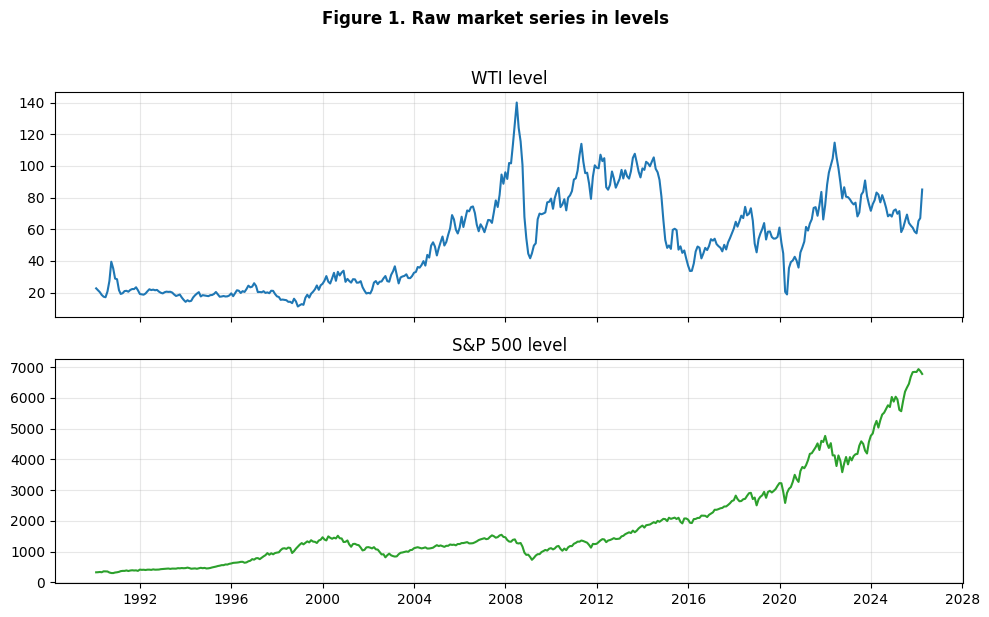

In [86]:
print("Table 2. Correlation matrix")
display(project_df[descriptive_columns].corr().round(3))

plot_level_series(monthly_market_data)  # on visualise d'abord les series en niveau avant de raisonner sur les rendements et variations

In [87]:
stationarity_columns = ["wti_return", "sp500_return", "hy_change", "term_spread", "gold_return", "cfnai", "ism_mfg"]

print("Table 3a. ADF stationarity tests")
display(run_adf_table(project_df, stationarity_columns))

Table 3a. ADF stationarity tests


,variable,n_obs,adf_stat,p_value,stationary_5pct
0,wti_return,433,-12.2010,0.0000,True
1,sp500_return,433,-20.6803,0.0000,True
2,hy_change,433,-10.4457,0.0000,True
3,term_spread,434,-3.3442,0.0130,True
4,gold_return,433,-3.3210,0.0140,True
5,cfnai,434,-15.2059,0.0000,True
6,ism_mfg,434,-5.6506,0.0000,True


In [88]:
print("Table 3b. Ljung-Box autocorrelation and Jarque-Bera normality tests")
display(run_ljungbox_jb_table(project_df, stationarity_columns))

Table 3b. Ljung-Box autocorrelation and Jarque-Bera normality tests


,variable,LB(6)_stat,LB(6)_pval,LB(12)_stat,LB(12)_pval,JB_stat,JB_pval,normal_5pct
0,wti_return,25.1900,0.0003,30.3900,0.0024,1934.6000,0.0000,False
1,sp500_return,5.1200,0.5286,12.3400,0.4187,76.9800,0.0000,False
2,hy_change,33.2700,0.0000,37.3100,0.0002,2224.4300,0.0000,False
3,term_spread,2268.5600,0.0000,3771.0100,0.0000,21.6500,0.0000,False
4,gold_return,4.7600,0.5744,19.6900,0.0732,15.4900,0.0004,False
5,cfnai,23.1900,0.0007,31.6200,0.0016,504675.4100,0.0000,False
6,ism_mfg,1440.0700,0.0000,1627.0900,0.0000,23.8000,0.0000,False


### Volatility clustering (ACF of squared returns)
Check whether volatility clustering is significant

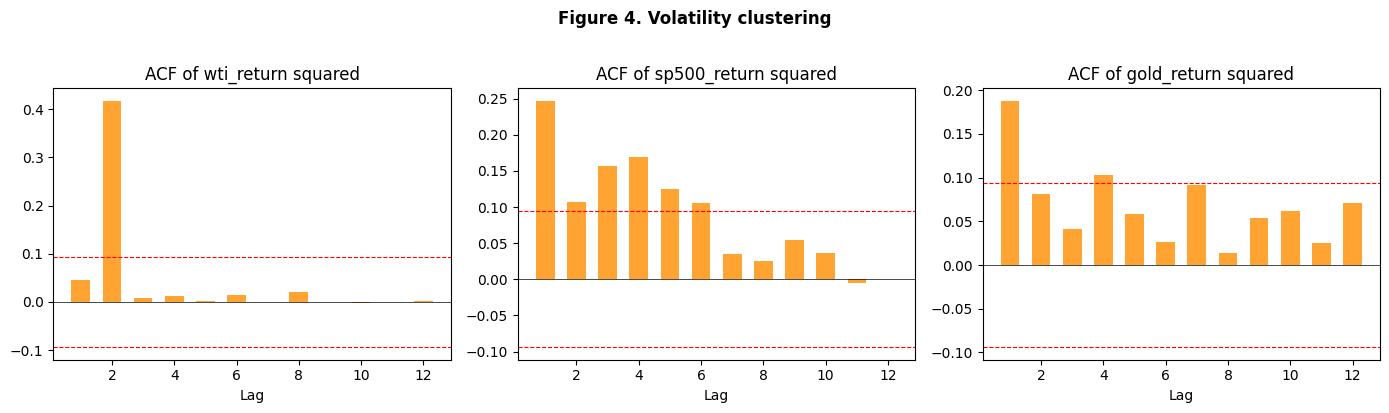

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["wti_return", "sp500_return", "gold_return"]):
    s = project_df[col].dropna().values
    acf_vals = acf(s**2, nlags=12, fft=True)
    T = len(s)
    ax.bar(range(1, 13), acf_vals[1:13], color="darkorange", width=0.6, alpha=0.8)
    ax.axhline(y=1.96/np.sqrt(T), color="red", linestyle="--", linewidth=0.8)
    ax.axhline(y=-1.96/np.sqrt(T), color="red", linestyle="--", linewidth=0.8)
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.set_title(f"ACF of {col} squared")
    ax.set_xlabel("Lag")
plt.suptitle("Figure 4. Volatility clustering", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [90]:
for col in ["wti_return", "sp500_return", "gold_return"]:
    lb = acorr_ljungbox(project_df[col].dropna()**2, lags=[6, 12], return_df=True)
    print(f"{col} squared: LB(6) p={lb.loc[6,'lb_pvalue']:.4f}, LB(12) p={lb.loc[12,'lb_pvalue']:.4f}")

wti_return squared: LB(6) p=0.0000, LB(12) p=0.0000
sp500_return squared: LB(6) p=0.0000, LB(12) p=0.0000
gold_return squared: LB(6) p=0.0003, LB(12) p=0.0005


# 8. Oil shock decomposition

This is the main part of the project. We will divide the increase of oil prices in two different reasons :

- a **demand-related :** high CFNAI → economy is growing → economy consumes oil → prices go up
- a **supply-related :** disruption in the supply chain (War in Iran) → prices go up

Now we will define how those two different shocks can be described by our models.

- **Fitted values :** Conceptually, the part of oil price movement explained by demand
- **Residuals :** What is not explained by demand → attributed to supply

In [91]:
decomposition_df, scratch_res = decompose_oil_returns_scratch(
    project_df,
    oil_return_col="wti_return",
    activity_col="cfnai",
    prefix="baseline",
)  # on construit la decomposition de base avec l'OLS calcule a la main

print("Table 4. Oil decomposition: r_wti = alpha + beta * CFNAI + epsilon")
display(ols_summary_df(scratch_res))
print(f"R squared = {scratch_res['R2']:.4f}, T = {scratch_res['T']}")

Table 4. Oil decomposition: r_wti = alpha + beta * CFNAI + epsilon


,coef,std_err,t_stat,p_value
const,0.0038,0.0049,0.7809,0.4353
cfnai,0.0184,0.0044,4.1777,0.0000


R squared = 0.0389, T = 433


In [92]:
print("Residual diagnostics:")
display(run_diagnostic_residuals(scratch_res["resid"]))  # on verifie rapidement si la decomposition de base laisse une forte structure residuelle

Residual diagnostics:


,lag,ACF,LB_stat,LB_pval,autocorrelated_5pct
0,6,0.0156,19.7300,0.0031,True
1,12,-0.0375,23.6300,0.0228,True


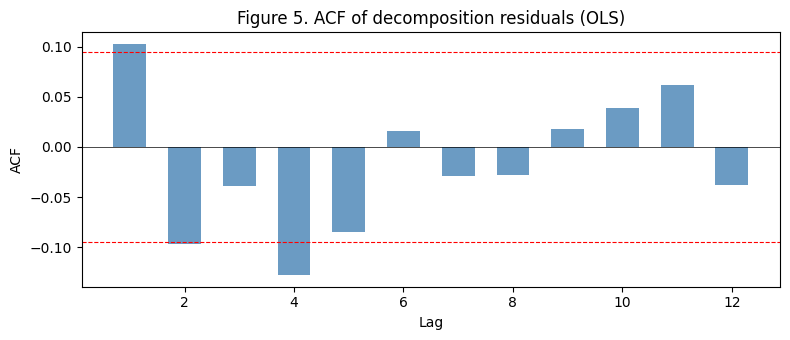

In [93]:
fig, ax = plt.subplots(figsize=(8, 3.5))
acf_vals = acf(scratch_res["resid"], nlags=12, fft=True)
T = len(scratch_res["resid"])
ax.bar(range(1, 13), acf_vals[1:13], color="steelblue", width=0.6, alpha=0.8)
ax.axhline(y=1.96/np.sqrt(T), color="red", linestyle="--", linewidth=0.8)
ax.axhline(y=-1.96/np.sqrt(T), color="red", linestyle="--", linewidth=0.8)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_title("Figure 5. ACF of decomposition residuals (OLS)")
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
plt.tight_layout()
plt.show()

The next figure shows how the total WTI return is divided between the demand component and the supply component.

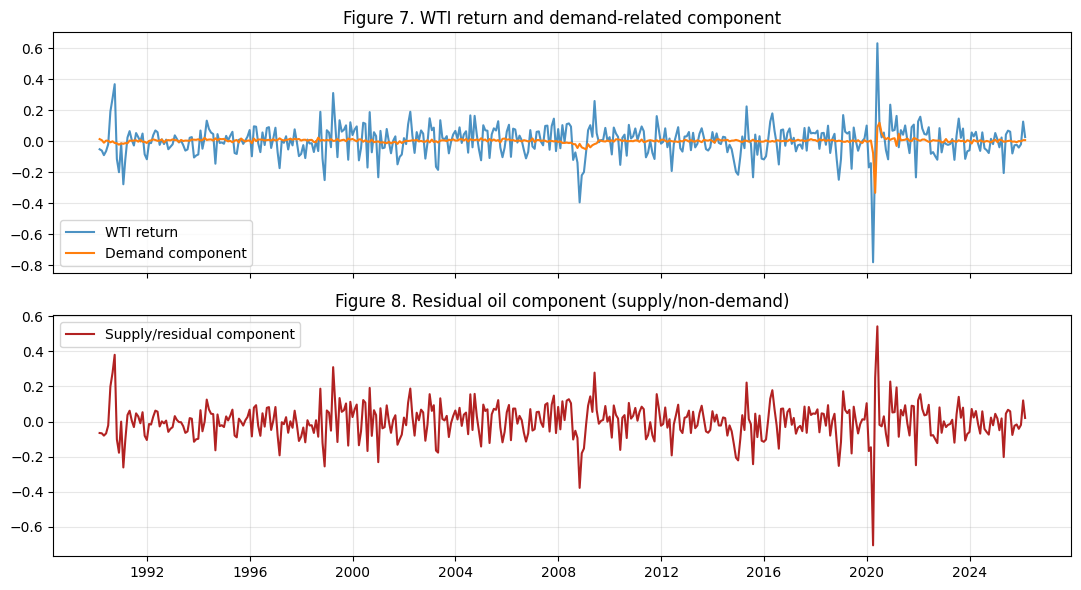

In [94]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(decomposition_df["date"], decomposition_df["wti_return"], label="WTI return", alpha=0.8)
axes[0].plot(decomposition_df["date"], decomposition_df["baseline_oil_demand_component"], label="Demand component", linewidth=1.5)
axes[0].set_title("Figure 7. WTI return and demand-related component")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomposition_df["date"], decomposition_df["baseline_oil_supply_component"], label="Supply/residual component", color="firebrick")
axes[1].set_title("Figure 8. Residual oil component (supply/non-demand)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8b. MA(1) robustness check

As described in figure 5, there is significant autocorrelation at lags 1, 2 and 4. Hence, we need to run an MA(1) robustness check.

In [95]:
sample = project_df[["wti_return", "cfnai"]].dropna()
ma1_res = estimate_ma1(sample["wti_return"].values, sample["cfnai"].values.reshape(-1, 1), ["cfnai"])  # on estime une version MA(1) compacte comme simple verification de robustesse

print("Table 5. OLS vs MA(1) comparison")
display(ma1_comparison_table(ma1_res))

Table 5. OLS vs MA(1) comparison


,parameter,OLS_coef,OLS_se,MLE_coef,MLE_se
0,const,0.0038,0.0049,0.0036,0.0056
1,cfnai,0.0184,0.0044,0.0154,0.0023
2,theta_MA1,NaN,NaN,0.1375,0.0452


In [96]:
print(f"MA(1) theta = {ma1_res['theta']:.4f}")
print(f"Sigma OLS = {np.sqrt(scratch_res['sigma2']):.4f}, Sigma MA(1) = {ma1_res['sigma']:.4f}")
print("Beta CFNAI moves from {:.4f} (OLS) to {:.4f} (MA(1)) -- the baseline decomposition remains broadly unchanged.".format(
    scratch_res["beta"][1], ma1_res["beta"][1]
))

MA(1) theta = 0.1375
Sigma OLS = 0.1023, Sigma MA(1) = 0.1013
Beta CFNAI moves from 0.0184 (OLS) to 0.0154 (MA(1)) -- the baseline decomposition remains broadly unchanged.


The Beta (CFNAI) and the Sigma are very similar between the OLS to the MA(1) → similar fit. Hence, we can keep the OLS.


# 9. Predictive regressions

In this section, we will run a predictive regression to check the effects of demand and supply driven shock on the SP500 and the UST credit spread, while controlling for the other variables.

In [97]:
target_map = {
    "sp500_return": "S&P 500 next-month return",
    "hy_change": "HY next-month change",
}

decomposition_models = {}

for target, label in target_map.items():
    decomp_model, decomp_sample = fit_predictive_regression(
        decomposition_df, dependent_col=target,
        predictor_cols=["baseline_oil_demand_component", "baseline_oil_supply_component", target, "term_spread", "gold_return", "sp500_realized_vol"],
        horizon=1, cov_type="HC1",
    )
    decomposition_models[target] = decomp_model
    print(f"Decomposition model: {label} (N = {len(decomp_sample)})")
    display(regression_results_table(decomp_model))
    for line in interpret_two_component_model(decomp_model, "baseline_oil_demand_component", "baseline_oil_supply_component"):
        print(f"  {line}")
    print("Residual diagnostics:")
    display(run_diagnostic_residuals(decomp_model.resid))
    print()

Decomposition model: S&P 500 next-month return (N = 432)


,coef,std_err,t_stat,p_value
const,0.0110,0.0062,1.7674,0.0772
baseline_oil_demand_component,0.0090,0.1357,0.0662,0.9472
baseline_oil_supply_component,-0.0377,0.0254,-1.4813,0.1385
sp500_return_current,0.0067,0.0638,0.1043,0.9169
term_spread,-0.0012,0.0022,-0.5559,0.5783
gold_return,-0.0420,0.0530,-0.7923,0.4282
sp500_realized_vol,-0.2694,0.6068,-0.4440,0.6570


  Demand-related oil component: coefficient is positive (0.0090) and not statistically significant at the 5% level (p-value = 0.9472).
  Supply-related oil component: coefficient is negative (-0.0377) and not statistically significant at the 5% level (p-value = 0.1385).
Residual diagnostics:


,lag,ACF,LB_stat,LB_pval,autocorrelated_5pct
0,6,-0.0827,5.2600,0.5111,False
1,12,0.0446,10.7500,0.5503,False



Decomposition model: HY next-month change (N = 432)


,coef,std_err,t_stat,p_value
const,0.1336,0.1060,1.2613,0.2072
baseline_oil_demand_component,0.9152,1.7373,0.5268,0.5983
baseline_oil_supply_component,0.8835,0.3773,2.3418,0.0192
hy_change_current,0.3221,0.0986,3.2682,0.0011
term_spread,-0.0420,0.0332,-1.2655,0.2057
gold_return,-0.0612,1.0029,-0.0610,0.9514
sp500_realized_vol,-11.5419,11.1668,-1.0336,0.3013


  Demand-related oil component: coefficient is positive (0.9152) and not statistically significant at the 5% level (p-value = 0.5983).
  Supply-related oil component: coefficient is positive (0.8835) and statistically significant at the 5% level (p-value = 0.0192).
Residual diagnostics:


,lag,ACF,LB_stat,LB_pval,autocorrelated_5pct
0,6,-0.0703,10.8900,0.0919,False
1,12,0.0564,15.4700,0.2169,False


## 9b. Stability of predictive coefficients
We will now examine if the estimated effects remain stable over time using a rolling window.


In [98]:
rolling_results = {}

for target in ["sp500_return", "hy_change"]:
    rolling_results[target] = rolling_predictive_coefficients(
        decomposition_df,
        dependent_col=target,
        predictor_cols=["baseline_oil_demand_component", "baseline_oil_supply_component", target, "term_spread", "gold_return", "sp500_realized_vol"],
        window=60,
        horizon=1,
    )  # on estime des coefficients glissants pour les actions et pour le credit

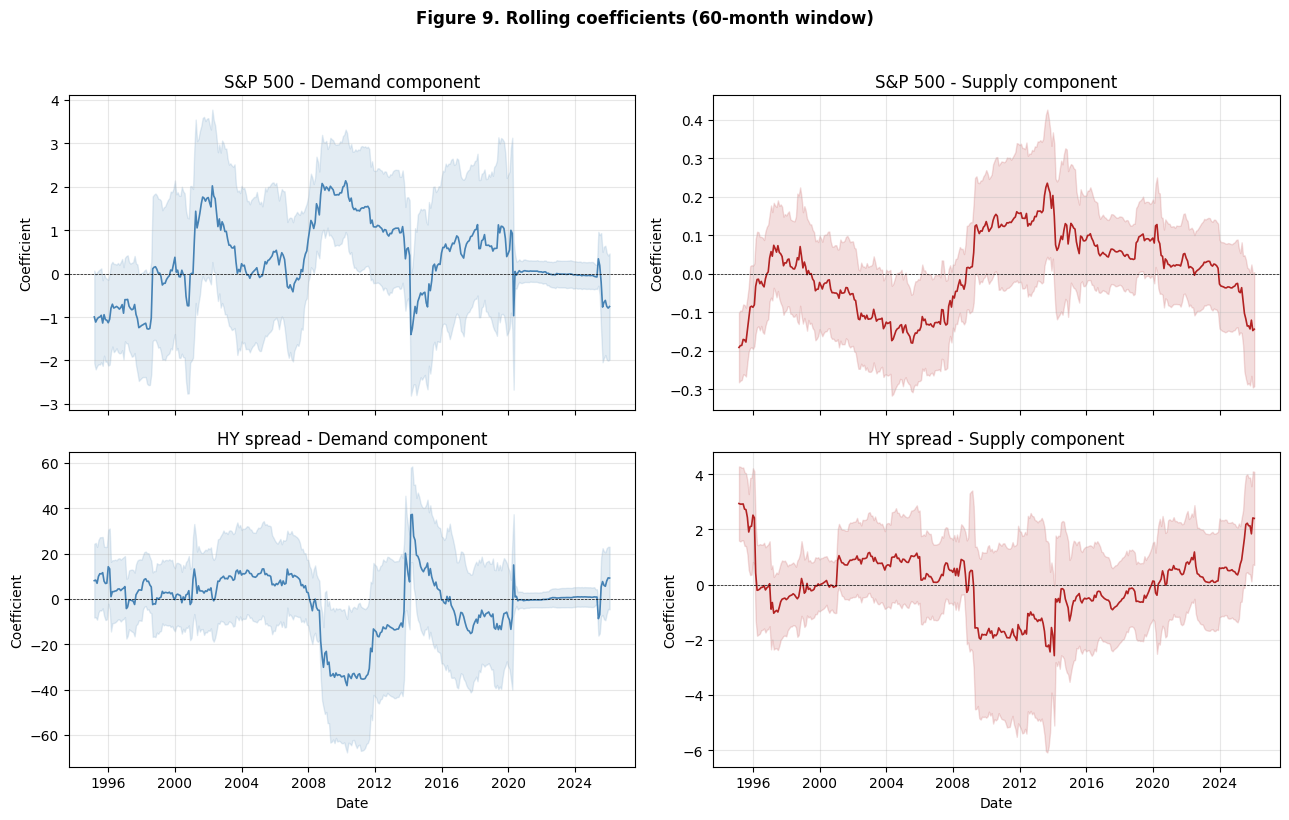

In [99]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex='col')
plot_specs = [
    ("sp500_return", "S&P 500", 0),
    ("hy_change", "HY spread", 1),
]
for target, label, row in plot_specs:
    roll = rolling_results[target]
    for col_idx, (comp, color, title) in enumerate([
        ("baseline_oil_demand_component", "steelblue", "Demand component"),
        ("baseline_oil_supply_component", "firebrick", "Supply component"),
    ]):
        ax = axes[row, col_idx]
        beta_col = f"beta_{comp}"
        se_col = f"se_{comp}"
        ax.plot(roll["date"], roll[beta_col], color=color, linewidth=1.2)
        ax.fill_between(roll["date"], roll[beta_col] - 2 * roll[se_col], roll[beta_col] + 2 * roll[se_col], alpha=0.15, color=color)
        ax.axhline(y=0, color="black", linewidth=0.5, linestyle="--")
        ax.set_title(f"{label} - {title}")
        ax.set_ylabel("Coefficient")
        ax.grid(True, alpha=0.3)

for ax in axes[1, :]:
    ax.set_xlabel("Date")

plt.suptitle("Figure 9. Rolling coefficients (60-month window)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 10. Causality tests

Using the Granger causality test, we will test whether lagged values of the supply and the demand of oil contain information for equity returns and credit spreads.

In [100]:
granger_specs = [
    ("baseline_oil_demand_component", "sp500_return"),
    ("baseline_oil_supply_component", "sp500_return"),
    ("baseline_oil_demand_component", "hy_change"),
    ("baseline_oil_supply_component", "hy_change"),
]
granger_tables = [granger_pvalue_table(decomposition_df, c, e, max_lag=3) for c, e in granger_specs]
print("Table 6. Granger causality p-values")
display(pd.concat(granger_tables, ignore_index=True))

Table 6. Granger causality p-values


,cause,effect,lag,p_value
0,baseline_oil_demand_component,sp500_return,1,0.6812
1,baseline_oil_demand_component,sp500_return,2,0.6780
2,baseline_oil_demand_component,sp500_return,3,0.9375
3,baseline_oil_supply_component,sp500_return,1,0.0652
4,baseline_oil_supply_component,sp500_return,2,0.0842
5,baseline_oil_supply_component,sp500_return,3,0.1690
6,baseline_oil_demand_component,hy_change,1,0.1577
7,baseline_oil_demand_component,hy_change,2,0.6904
8,baseline_oil_demand_component,hy_change,3,0.0050
9,baseline_oil_supply_component,hy_change,1,0.0013


# 11. Small VARs and impulse responses

We estimate trivariate VARs in order to determine how SP500 returns and UST spreads respond to demand or supply driven oil shocks over 12 months, using impulse response functions.

In [101]:
def run_component_var(df, market_col, market_label):
    var_cols = [
        "baseline_oil_demand_component",
        "baseline_oil_supply_component",
        market_col,
    ]  # on construit un petit VAR centre sur la composante demande, la composante residuelle et la variable financiere

    var_df = df[["date"] + var_cols].dropna().set_index("date")  # on garde un panel mensuel propre sans valeurs manquantes
    var_model = VAR(var_df)  # on initialise le modele VAR
    lag_selection = var_model.select_order(maxlags=3)  # on limite la recherche a 3 retards pour rester parcimonieux

    chosen_lag = lag_selection.selected_orders["bic"]  # on commence par le lag suggere par le BIC
    if chosen_lag == 0:
        chosen_lag = max(1, lag_selection.selected_orders["aic"])  # si le BIC propose 0, on impose au moins 1 retard

    var_results = var_model.fit(chosen_lag)  # on estime le VAR final

    print(f"\nVAR for {market_label}")
    print("Lag selection:")
    display(pd.DataFrame([lag_selection.selected_orders], index=["selected_lag"]))  # on affiche les choix de lag des criteres d'information
    print(f"Chosen lag: {chosen_lag}")
    print(f"Stable: {var_results.is_stable()}")  # on verifie que les racines restent dans le cercle unite

    return var_cols, var_results

In [102]:
def plot_component_var_irfs(var_cols, var_results, market_col, market_label, figure_title):
    irf = var_results.irf(12)  # on regarde les reponses impulsionnelles sur 12 mois
    irf_err = irf.errband_mc(orth=True, repl=300, signif=0.05, seed=42)  # on ajoute des bandes de confiance par simulation Monte Carlo

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    market_idx = var_cols.index(market_col)  # on repere la variable financiere dans le systeme

    for ax, impulse_name, color, title in [
        (axes[0], "baseline_oil_demand_component", "steelblue", f"{market_label} response to a DEMAND oil shock"),
        (axes[1], "baseline_oil_supply_component", "firebrick", f"{market_label} response to a SUPPLY oil shock"),
    ]:
        impulse_idx = var_cols.index(impulse_name)  # on repere le type de choc petrolier
        values = irf.orth_irfs[:, market_idx, impulse_idx]  # on extrait la reponse moyenne de la variable financiere
        lower = irf_err[0][:, market_idx, impulse_idx]  # borne inferieure de l'intervalle de confiance
        upper = irf_err[1][:, market_idx, impulse_idx]  # borne superieure de l'intervalle de confiance
        ax.plot(range(len(values)), values, color=color, linewidth=1.5)
        ax.fill_between(range(len(values)), lower, upper, alpha=0.15, color=color)
        ax.axhline(y=0, color="black", linewidth=0.5, linestyle="--")  # la ligne zero aide a lire le signe de la reponse
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Months")
        ax.set_ylabel("Response")
        ax.grid(True, alpha=0.3)

    plt.suptitle(figure_title, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


VAR for S&P 500 return
Lag selection:


,aic,bic,hqic,fpe
selected_lag,2,1,1,2


Chosen lag: 1
Stable: True


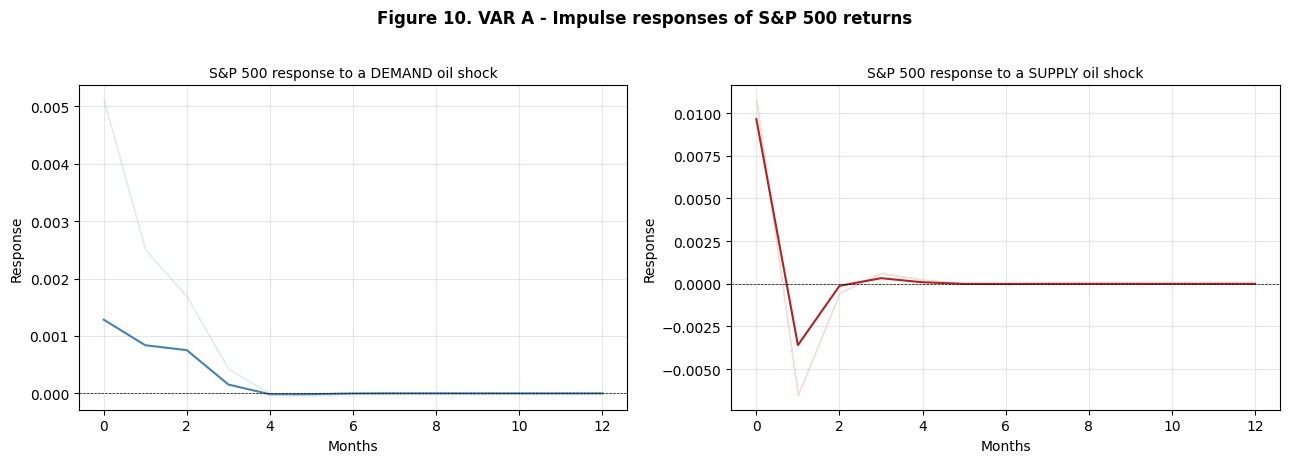

In [103]:
var_a_cols, var_a_res = run_component_var(
    decomposition_df,
    market_col="sp500_return",
    market_label="S&P 500 return",
)  # on lance le petit VAR pour le marche actions

plot_component_var_irfs(
    var_a_cols,
    var_a_res,
    market_col="sp500_return",
    market_label="S&P 500",
    figure_title="Figure 10. VAR A - Impulse responses of S&P 500 returns",
)  # on compare la reponse des actions a un choc demande et a un choc residuel


VAR for HY change
Lag selection:


,aic,bic,hqic,fpe
selected_lag,3,1,1,3


Chosen lag: 1
Stable: True


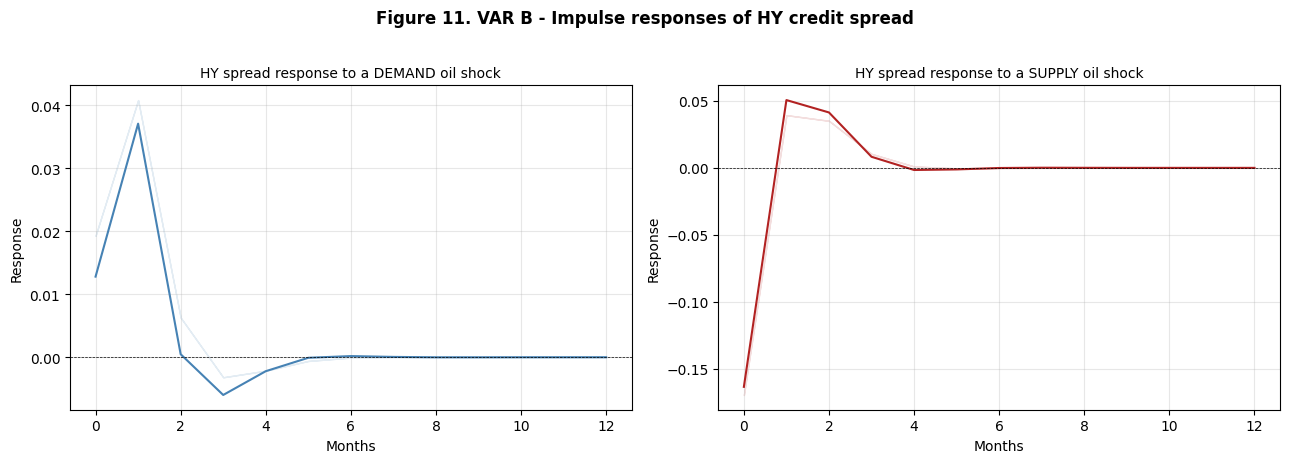

In [104]:
var_b_cols, var_b_res = run_component_var(
    decomposition_df,
    market_col="hy_change",
    market_label="HY change",
)  # on lance le petit VAR pour les spreads de credit

plot_component_var_irfs(
    var_b_cols,
    var_b_res,
    market_col="hy_change",
    market_label="HY spread",
    figure_title="Figure 11. VAR B - Impulse responses of HY credit spread",
)  # on compare la reponse du credit a un choc demande et a un choc residuel

# 12. Out-of-sample forecasting
In this section we will address the second part of the question : **Can this distinction improve the prediction of equity returns and credit spreads?**
 We compare three models:
1. a historical mean benchmark,
2. a model with raw oil returns,
3. a model with the oil decomposition.

We then compare them using the Root Mean Squared Error (RMSE) and the Mean Absolute Error (MAE).

In [105]:
forecast_rows = []

for target, label in target_map.items():
    _, metrics_df = rolling_forecast_comparison(
        decomposition_df,
        target_col=target,
        raw_oil_col="wti_return",
        demand_col="baseline_oil_demand_component",
        supply_col="baseline_oil_supply_component",
        controls=["term_spread", "gold_return", "sp500_realized_vol"],
        start_share=0.6,
    )  # on compare hors echantillon un benchmark simple, le petrole brut et la decomposition

    metrics_df = metrics_df.copy()
    metrics_df.insert(0, "target", label)  # on garde le nom de la variable predite pour construire un tableau unique
    forecast_rows.append(metrics_df)

forecast_summary = pd.concat(forecast_rows, ignore_index=True)  # on regroupe les resultats de forecast dans une seule table

print("Table 12. Out-of-sample forecast comparison")
display(forecast_summary)

Table 12. Out-of-sample forecast comparison


,target,model,rmse,mae
0,S&P 500 next-month return,benchmark,0.0404,0.0308
1,S&P 500 next-month return,raw_oil_model,0.0417,0.0312
2,S&P 500 next-month return,decomposition_model,0.0436,0.0318
3,HY next-month change,benchmark,0.5526,0.3816
4,HY next-month change,raw_oil_model,0.5814,0.4027
5,HY next-month change,decomposition_model,0.5845,0.4047


# 13. Robustness checks

After the main results, we will conduct robustness tests. We will follow the same approach but modify :
1. Use Brent instead of WTI and MSCI EM instead of SP500
2. Split the sample into three historical periods (90'-07', 08'-14', 15'-26')

In [106]:
brent_df, _ = decompose_oil_returns(
    decomposition_df,
    oil_return_col="brent_return",
    activity_col="cfnai",
    prefix="brent",
)  # on refait la decomposition avec Brent pour verifier que le resultat ne depend pas du seul WTI

brent_model, brent_sample = fit_predictive_regression(
    brent_df,
    dependent_col="sp500_return",
    predictor_cols=["brent_oil_demand_component", "brent_oil_supply_component", "sp500_return", "term_spread", "gold_return", "sp500_realized_vol"],
    horizon=1,
    cov_type="HC1",
)  # on re-estime la regression predictive sur les actions avec la decomposition Brent

em_model, em_sample = fit_predictive_regression(
    decomposition_df,
    dependent_col="msci_em_return",
    predictor_cols=["baseline_oil_demand_component", "baseline_oil_supply_component", "msci_em_return", "term_spread", "gold_return", "sp500_realized_vol"],
    horizon=1,
    cov_type="HC1",
)  # on teste si le resultat s'etend a un autre marche actions que le S&P 500

robustness_rows = []
for name, model, demand_name, supply_name in [
    ("Brent instead of WTI", brent_model, "brent_oil_demand_component", "brent_oil_supply_component"),
    ("MSCI EM instead of S&P", em_model, "baseline_oil_demand_component", "baseline_oil_supply_component"),
]:
    robustness_rows.append({
        "check": name,
        "demand_coef": model.params.get(demand_name, np.nan),
        "demand_pval": model.pvalues.get(demand_name, np.nan),
        "supply_coef": model.params.get(supply_name, np.nan),
        "supply_pval": model.pvalues.get(supply_name, np.nan),
    })  # on resume chaque robustesse par les coefficients et p-values des deux composantes petrolieres

print("Table 13. Robustness checks")
display(pd.DataFrame(robustness_rows).round(4))

Table 13. Robustness checks


,check,demand_coef,demand_pval,supply_coef,supply_pval
0,Brent instead of WTI,0.0108,0.9587,-0.0431,0.1258
1,MSCI EM instead of S&P,0.1636,0.2628,-0.0573,0.0803


In [107]:
sub_periods = [
    ("1990-2007", "1990-01-01", "2008-01-01"),
    ("2008-2014", "2008-01-01", "2015-01-01"),
    ("2015-2026", "2015-01-01", "2027-01-01"),
]  # on coupe l'echantillon en grandes periodes historiques pour voir si le resultat change beaucoup

sub_rows = []
for target, label in [("sp500_return", "S&P 500"), ("hy_change", "HY change")]:
    for period_label, start, end in sub_periods:
        sub = decomposition_df[(decomposition_df["date"] >= start) & (decomposition_df["date"] < end)]  # on isole la sous-periode consideree
        if len(sub) < 30:
            continue
        sub_model, sub_sample = fit_predictive_regression(
            sub,
            dependent_col=target,
            predictor_cols=["baseline_oil_demand_component", "baseline_oil_supply_component", target, "term_spread", "gold_return", "sp500_realized_vol"],
            horizon=1,
            cov_type="HC1",
        )  # on re-estime le modele de base dans chaque sous-periode et pour chaque marche
        sub_rows.append({
            "target": label,
            "period": period_label,
            "N": len(sub_sample),
            "demand_coef": sub_model.params.get("baseline_oil_demand_component", np.nan),
            "demand_pval": sub_model.pvalues.get("baseline_oil_demand_component", np.nan),
            "supply_coef": sub_model.params.get("baseline_oil_supply_component", np.nan),
            "supply_pval": sub_model.pvalues.get("baseline_oil_supply_component", np.nan),
        })

print("Table 14. Sub-period analysis")
display(pd.DataFrame(sub_rows).round(4))

Table 14. Sub-period analysis


,target,period,N,demand_coef,demand_pval,supply_coef,supply_pval
0,S&P 500,1990-2007,214,0.1677,0.6440,-0.1058,0.0012
1,S&P 500,2008-2014,83,1.0151,0.1406,0.1363,0.0438
2,S&P 500,2015-2026,133,-0.0380,0.6000,0.0043,0.9122
3,HY change,1990-2007,214,7.2571,0.1333,1.5121,0.0042
4,HY change,2008-2014,83,-10.3137,0.6204,-1.5613,0.2454
5,HY change,2015-2026,133,0.8838,0.6209,0.3395,0.4926


# 14. Main conclusions

The empirical results of our study suggest that the distinction between demand and supply related oil movements has a larger impact for **credit risk** than for **equity returns** in the US Market. The supply component is more significant for the **credit risk** than the demand component. However, for the SP500 none of them come with a significant score.

Regarding the second part of the question, the decomposition model underperforms the historical mean benchmark for both markets. Hence, even for the credit spread with a significant signal, it is too weak to beat the simple mean.

More extensive analyze and conclusions can be found in the PDF.

In [108]:
print("Main takeaway for S&P 500 returns")
for line in interpret_two_component_model(decomposition_models["sp500_return"], "baseline_oil_demand_component", "baseline_oil_supply_component"):
    print(f"  {line}")

print("\nMain takeaway for HY changes")
for line in interpret_two_component_model(decomposition_models["hy_change"], "baseline_oil_demand_component", "baseline_oil_supply_component"):
    print(f"  {line}")


Main takeaway for S&P 500 returns
  Demand-related oil component: coefficient is positive (0.0090) and not statistically significant at the 5% level (p-value = 0.9472).
  Supply-related oil component: coefficient is negative (-0.0377) and not statistically significant at the 5% level (p-value = 0.1385).

Main takeaway for HY changes
  Demand-related oil component: coefficient is positive (0.9152) and not statistically significant at the 5% level (p-value = 0.5983).
  Supply-related oil component: coefficient is positive (0.8835) and statistically significant at the 5% level (p-value = 0.0192).
